In [ ]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from astropy.io import fits
from astropy import units as u
import matplotlib.pyplot as plt
from specutils.analysis import line_flux
from astropy.nddata import StdDevUncertainty
from specutils import Spectrum, SpectralRegion


#Define source path where the files are
source = Path('/home/nicolas/Documents/Research/PhD/JWST-Data/Medium_Resolution/Spectra1D')
jades_folder = source / 'JADES'
catalogue_folder = source / 'Catalogue'


%matplotlib widget


# ///////////////////  Plot Setting  ////////////////////////////

# Latex rendering
plt.rc('font', **{'family': 'serif', 'serif': ['palatino']}) #Helvetica
plt.rc('text', usetex=True)
plt.rc('font', weight='bold')


# --- Cosmology palette (normalized RGB) ---
COSMO_COLORS = {
    "deep_blue": (30/255, 60/255, 120/255),
    "warm_gold": (200/255, 140/255, 0/255),
    "dark_teal": (0/255, 110/255, 110/255),
    "soft_crimson": (150/255, 40/255, 40/255),
    "cool_gray": (120/255, 120/255, 120/255),
    }

sns.set_theme(
    style="ticks",
    context='paper',
    rc={
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "axes.grid": True,
    })

sns.set_palette([
    COSMO_COLORS["deep_blue"],
    "black",
    COSMO_COLORS["warm_gold"],
    COSMO_COLORS["cool_gray"],
    COSMO_COLORS["dark_teal"],
    COSMO_COLORS["soft_crimson"],
    ])

#General Settings
plt.rc('axes', titlesize=18)     # fontsize of the axes title
plt.rc('axes', labelsize=18)     # fontsize of the x and y labels
plt.rc('axes', linewidth=1.65 )   # width of the frame
plt.rc('xtick', labelsize=16)    # fontsize of the tick labels
plt.rc('ytick', labelsize=16)    # fontsize of the tick labels
plt.rc('legend', fontsize=12)    # legend fontsize
plt.rc('font', size=18)          # controls default text sizes


#Extract data with Pandas
df = pd.read_csv("list_of_candidates.tsv", sep='\t')
ID_array = df["NIRSpec_ID"]
z_array = df["redshift"]
JADES_files = df["JADES_FILENAME_F170LP-G235M"]
CAT_files = df["CAT_FILENAME_F170LP-G235M"]


In [14]:
#==================================================
#/// /////         Functions                 //////
#==================================================
def flux_stdDev(lambda_array, flux_array, regionLeft, regionRight):

    #Compute the standard deviation of the flux around a given line
    lambda_array = np.array(lambda_array)
    flux_array = np.array(flux_array)

    # Crear máscara booleana para el rango deseado
    lambda_ini = regionLeft[0]
    lambda_end = regionLeft[1]
    mask_left = (lambda_array >= lambda_ini) & (lambda_array <= lambda_end)

    lambda_ini = regionRight[0]
    lambda_end = regionRight[1]
    mask_right = (lambda_array >= lambda_ini) & (lambda_array <= lambda_end)

    # Extraer los valores correspondientes
    flux_left = flux_array[mask_left]
    flux_right = flux_array[mask_right]

    stdDev_left = np.std(flux_left)
    stdDev_right = np.std(flux_right)

    return (stdDev_left + stdDev_right)/2
#------------------------------------------------
#
#------------------------------------------------
def compute_line_flux(lamb, flux, region, z):
    
    r_ini = region[0] 
    r_end = region[1] 
    vlight = 2.99792458e-5 
    
    with warnings.catch_warnings(): #ignore warnings
        warnings.simplefilter('ignore')


        if np.isfinite(r_ini) and np.isfinite(r_end):

            #Flux Uncerainty
            if region=='Ha_region' or region=='Hb_region':
                flux_err = flux_stdDev(lamb.value, flux.value, [r_ini - 50, r_ini], [r_end, r_end + 50]) 
            else:
                flux_err = flux_stdDev(lamb.value, flux.value, [4950 - 50, 4950], [5015, 5015 + 50]) 

            flux_err_Jy = flux_err * np.ones(len(flux)) * u.Jy
            flux_uncertainty = StdDevUncertainty(flux_err_Jy)
            flux_err_Jy = flux_err * np.ones(len(flux)) * u.Jy
            flux_uncertainty = StdDevUncertainty(flux_err_Jy)

            spectrum = Spectrum(spectral_axis=lamb, flux=flux, uncertainty=flux_uncertainty)

    
            try:
                l_flux = line_flux(spectrum, regions=SpectralRegion(r_ini* u.AA, r_end* u.AA))
                l_flux_unc = l_flux.uncertainty
                #Convert to ergs s-1 cm-2
                l_flux = l_flux.value * vlight / ((1+float(z))*np.mean([r_ini, r_end]))**2
                l_flux_unc = l_flux_unc.value * vlight / ((1+float(z))*np.mean([r_ini, r_end]))**2

        
            except IndexError:
                l_flux = np.nan
                l_flux_unc = np.nan

        else:
            l_flux = np.nan
            l_flux_unc = np.nan


    return l_flux, l_flux_unc
#------------------------------------------------
#------------------------------------------------            
def save_line_fluxes(index, dline):
    
    
    z = z_array[index]
    #Extract file to use as input in compute_EW()
    jades_file = jades_folder / JADES_files[index]
    
    z = z_array[index]    
    
    # ===== JADES =====
    with fits.open(jades_file) as f:
        specdata = f[1].data
        
        #Flux vector
        flux = specdata['FLUX']  #flux in erg cm-2 s-1 AA-1'
        mask = np.isfinite(flux)
        flux_erg = flux[mask]
        
        #Compute rest wavelength
        lambda_obs = specdata['WAVELENGTH'] * 1e-6 / 1e-10 #convert from um to AA.
        lambda_rest = lambda_obs[mask] / (1.+float(z))
    
        flux = flux_erg * lambda_obs[mask]**2 / 2.99792458e-5


        flux_Jy = flux * u.Jy
        lambda_rest_AA = lambda_rest *u.AA
        
        Ha_region = [6563-dline, 6563 + dline ]
        Ha_flux, Ha_flux_unc = compute_line_flux(lambda_rest_AA, flux_Jy, Ha_region, z) 
    

        Hb_region = [4861-dline, 4861 + dline ]
        Hb_flux, Hb_flux_unc = compute_line_flux(lambda_rest_AA, flux_Jy, Hb_region, z) 


        N2_region = [6583-dline, 6583 + dline ]
        N2_flux, N2_flux_unc = compute_line_flux(lambda_rest_AA, flux_Jy, N2_region, z)     

        O3_region = [5007-dline, 5007 + dline ]
        O3_flux, O3_flux_unc = compute_line_flux(lambda_rest_AA, flux_Jy, O3_region, z)

        o3_region = [4959-dline, 4959 + dline ]
        o3_flux, o3_flux_unc = compute_line_flux(lambda_rest_AA, flux_Jy, o3_region, z)


    # ==== Save the data ====
        
    return Ha_flux, Ha_flux_unc, Hb_flux, Hb_flux_unc, N2_flux, N2_flux_unc, O3_flux, O3_flux_unc, o3_flux, o3_flux_unc

#------------------------------------------------
#
#------------------------------------------------

In [15]:
def compute_sigmas(flux, flux_err):
    sigmas = [ np.abs ( flux[i] - flux[i+1] ) / np.sqrt( flux_err[i]**2 + flux_err[i+1]**2 ) for i in range(len(flux)-1)]
    return sigmas

In [21]:
def plot_variation_significance(index):

    start = 3
    end = 15
    step = 1

    # Compute fluxes for different widths
    Ha_flux_around_line = [save_line_fluxes(index, dl)[0] for dl in range(start, end, step)]
    Ha_flux_around_line_perr = [save_line_fluxes(index, dl)[0] - save_line_fluxes(index, dl)[1] for dl in range(start, end, step)]
    Ha_flux_around_line_merr = [save_line_fluxes(index, dl)[0] + save_line_fluxes(index, dl)[1] for dl in range(start, end, step)]

    Hb_flux_around_line = [save_line_fluxes(index, dl)[2] for dl in range(start, end, step)]
    Hb_flux_around_line_perr = [save_line_fluxes(index, dl)[2] - save_line_fluxes(index, dl)[3] for dl in range(start, end, step)]
    Hb_flux_around_line_merr = [save_line_fluxes(index, dl)[2] + save_line_fluxes(index, dl)[3] for dl in range(start, end, step)]

    N2_flux_around_line = [save_line_fluxes(index, dl)[4] for dl in range(start, end, step)]
    N2_flux_around_line_perr = [save_line_fluxes(index, dl)[4] - save_line_fluxes(index, dl)[5] for dl in range(start, end, step)]
    N2_flux_around_line_merr = [save_line_fluxes(index, dl)[4] + save_line_fluxes(index, dl)[5] for dl in range(start, end, step)]

    O3_flux_around_line = [save_line_fluxes(index, dl)[6] for dl in range(start, end, step)]
    O3_flux_around_line_perr = [save_line_fluxes(index, dl)[6] - save_line_fluxes(index, dl)[7] for dl in range(start, end, step)]
    O3_flux_around_line_merr = [save_line_fluxes(index, dl)[6] + save_line_fluxes(index, dl)[7] for dl in range(start, end, step)]

    O3_flux_around_line = [save_line_fluxes(index, dl)[8] for dl in range(start, end, step)]
    O3_flux_around_line_perr = [save_line_fluxes(index, dl)[8] - save_line_fluxes(index, dl)[9] for dl in range(start, end, step)]  
    O3_flux_around_line_merr = [save_line_fluxes(index, dl)[8] + save_line_fluxes(index, dl)[9] for dl in range(start, end, step)]

    # Plot fluxes
    x = np.arange(start, end, step)
    plt.figure()
    plt.plot(x, Ha_flux_around_line, color='red', label=r'$H\alpha$')
    plt.plot(x, Hb_flux_around_line, color='green', label=r'$H\beta$')
    plt.plot(x, N2_flux_around_line, color='blue', label=r'[NII]')

    plt.plot(x, Ha_flux_around_line_perr, linestyle='dashed', color='red')
    plt.plot(x, Ha_flux_around_line_merr, linestyle='dashed', color='red')
    plt.fill_between(x, Ha_flux_around_line_perr, Ha_flux_around_line_merr, color='red', alpha=0.4)

    plt.plot(x, Hb_flux_around_line_perr, linestyle='dashed', color='green')
    plt.plot(x, Hb_flux_around_line_merr, linestyle='dashed', color='green')
    plt.fill_between(x, Hb_flux_around_line_perr, Hb_flux_around_line_merr, color='green', alpha=0.4)

    plt.plot(x, N2_flux_around_line_perr, linestyle='dashed', color='blue')
    plt.plot(x, N2_flux_around_line_merr, linestyle='dashed', color='blue')
    plt.fill_between(x, N2_flux_around_line_perr, N2_flux_around_line_merr, color='blue', alpha=0.4)

    plt.minorticks_on()
    plt.xlabel('Width (Angstroms)')
    plt.ylabel(r'Flux ')
    plt.title('ID=' + str(ID_array[index]) + ', z=' + str(z_array[index]))
    plt.legend(loc='best')
    plt.show()

    
    Ha_flux_around_line_err = [ save_line_fluxes(index, dl)[1] for dl in range(start, end, step)]
    Hb_flux_around_line_err = [ save_line_fluxes(index, dl)[3] for dl in range(start, end, step)]
    N2_flux_around_line_err = [ save_line_fluxes(index, dl)[5] for dl in range(start, end, step)]
    O3_flux_around_line_err = [ save_line_fluxes(index, dl)[7] for dl in range(start, end, step)]
    o3_flux_around_line_err = [ save_line_fluxes(index, dl)[9] for dl in range(start, end, step)]

    Ha_sigmas = compute_sigmas(Ha_flux_around_line, Ha_flux_around_line_err)
    Hb_sigmas = compute_sigmas(Hb_flux_around_line, Hb_flux_around_line_err)
    N2_sigmas = compute_sigmas(N2_flux_around_line, N2_flux_around_line_err)
    O3_sigmas = compute_sigmas(O3_flux_around_line, O3_flux_around_line_err)
    o3_sigmas = compute_sigmas(O3_flux_around_line, o3_flux_around_line_err)    

    # Plot sigmas
    plt.figure()
    plt.plot(x[:-1], Ha_sigmas, color='red', label=r'$H\alpha$' , linestyle='None', marker='o')
    plt.plot(x[:-1], Hb_sigmas, color='green', label=r'$H\beta$', linestyle='None', marker='x')
    plt.plot(x[:-1], N2_sigmas, color='blue', label=r'$N II$'   , linestyle='None', marker='^')

    
    plt.minorticks_on()
    plt.xlabel('Width (Angstroms)')
    plt.ylabel(r'$(\delta Flux_i - Flux_{i+1}) $')

    plt.legend(loc='best')
    plt.show()

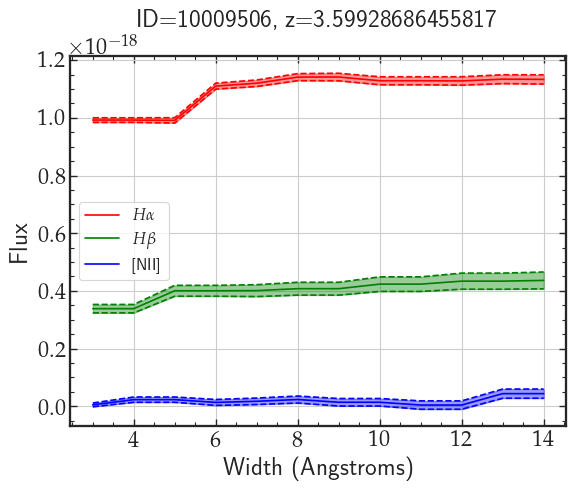

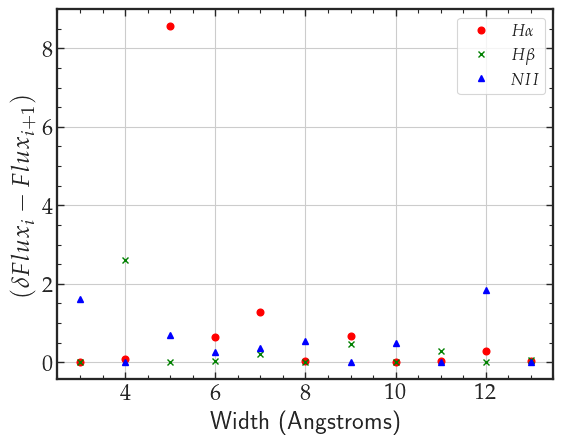

In [22]:
plot_variation_significance(49)